In [2]:
import pandas as pd

In [3]:
df = pd.read_csv(r'/kaggle/input/datasets/evelynuntariady/preproceesed-4k/preprocessed_data_4k.csv')

In [4]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'text_id', 'annotators_id', 'text',
       'initial_paragraph', 'topic', 'is_noise_or_spam_text',
       'related_to_election_2024', 'toxicity', 'polarized',
       'profanity_obscenity', 'threat_incitement_to_violence', 'insults',
       'identity_attack', 'sexually_explicit',
       'agreement_is_noise_or_spam_text', 'agreement_related_to_election_2024',
       'agreement_toxicity', 'agreement_polarized',
       'agreement_profanity_obscenity',
       'agreement_threat_incitement_to_violence', 'agreement_insults',
       'agreement_identity_attack', 'agreement_sexually_explicit',
       'cleaned_text'],
      dtype='object')

In [5]:
df.drop(columns =['Unnamed: 0.1', 'Unnamed: 0', 'agreement_is_noise_or_spam_text', 'agreement_related_to_election_2024',
        'agreement_toxicity','agreement_polarized', 'agreement_profanity_obscenity', 'agreement_threat_incitement_to_violence',
        'agreement_insults','agreement_identity_attack', 'agreement_sexually_explicit'], inplace = True)

In [6]:
labels = [
'is_noise_or_spam_text',
'related_to_election_2024',
'toxicity',
'polarized',
'profanity_obscenity',
'threat_incitement_to_violence',
'insults',
'identity_attack',
'sexually_explicit'
]

for col in labels:
    print(df[col].value_counts())

is_noise_or_spam_text
0    3936
Name: count, dtype: int64
related_to_election_2024
0    3401
1     535
Name: count, dtype: int64
toxicity
0    2000
1    1936
Name: count, dtype: int64
polarized
0    2000
1    1936
Name: count, dtype: int64
profanity_obscenity
0    3698
1     238
Name: count, dtype: int64
threat_incitement_to_violence
0    3853
1      83
Name: count, dtype: int64
insults
0    3231
1     705
Name: count, dtype: int64
identity_attack
0    3210
1     726
Name: count, dtype: int64
sexually_explicit
0    3894
1      42
Name: count, dtype: int64


# NLP Preprocessed

In [7]:
slang_dict = {
    "gk": "tidak",
    "ga": "tidak",
    "nggak": "tidak",
    "yg": "yang",
    "lu": "kamu",
    "loe": "kamu",
    "gw": "saya",
    "gue": "saya",
    "bgt": "banget",
    "dgn": "dengan",
    "krn": "karena",
    "aja": "saja",
    "trs": "terus"
}

In [8]:
import re

def normalize_slang(text, slang_dict):
    words = text.split()
    return " ".join([slang_dict.get(w.lower(), w) for w in words])

def preprocess_text(text, slang_dict, lowercase=True):
    if not isinstance(text, str):
        return ""

    # 1. remove username (@user)
    text = re.sub(r'@\w+', '', text)

    # 2. remove URL
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # 3. remove numbers
    text = re.sub(r'\d+', '', text)

    # 4. remove unwanted symbols (keep .,!?)
    text = re.sub(r'[^\w\s.,!?]', '', text)

    # 5. normalize slang
    text = normalize_slang(text, slang_dict)

    # 6. normalize repeated chars (contoh: anjiiing → anjiing)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # 7. lowercase (optional)
    if lowercase:
        text = text.lower()

    # 8. remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [9]:
from tqdm import tqdm
tqdm.pandas()

df['processed_text'] = df['cleaned_text'].progress_apply(
    lambda x: preprocess_text(x, slang_dict)
)

100%|██████████| 3936/3936 [00:00<00:00, 17329.52it/s]


In [10]:
x = df['processed_text']
y = df['toxicity']

In [11]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify = y, random_state=42)

In [13]:
train_df = pd.DataFrame({"processed_text": x_train, "label": y_train})
test_df = pd.DataFrame({"processed_text": x_test, "label": y_test})

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "test": Dataset.from_pandas(test_df)
})

In [ ]:
from huggingface_hub import login
login("key")

# Model Stage 1

In [15]:
from transformers import AutoTokenizer, Trainer, TrainingArguments, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("indolem/indobertweet-base-uncased")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [16]:
def tokenize(batch):
    return tokenizer(
        batch["processed_text"],   # atau cleaned_text / processed_text
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [17]:
tokenized_datasets_1 = dataset.map(tokenize, batched=True)

tokenized_datasets_1 = tokenized_datasets_1.remove_columns(["processed_text"])
tokenized_datasets_1 = tokenized_datasets_1.rename_column("label", "labels")
tokenized_datasets_1.set_format("torch")

train_dataset_1 = tokenized_datasets_1["train"]
test_dataset_1 = tokenized_datasets_1["test"]

Map:   0%|          | 0/3148 [00:00<?, ? examples/s]

Map:   0%|          | 0/788 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification

model_s1 = AutoModelForSequenceClassification.from_pretrained(
    "indolem/indobertweet-base-uncased",
    num_labels=2
)

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

In [19]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
def compute_metrics_s1(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

In [20]:
from transformers import TrainingArguments, Trainer

args_s1 = TrainingArguments(
    output_dir="./model_toxicity",
    num_train_epochs=5,
    logging_steps=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate = 1e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)

trainer_s1 = Trainer(
    model=model_s1,
    args=args_s1,
    train_dataset=train_dataset_1,
    eval_dataset=test_dataset_1,
    compute_metrics=compute_metrics_s1
)

In [21]:
trainer_s1.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.168678,1.015406,0.771574,0.791183
2,1.311296,0.981153,0.769036,0.763636
3,0.292959,0.967228,0.796954,0.802956
4,0.496822,0.994468,0.791878,0.797030
5,0.656999,1.006333,0.795685,0.795944


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=985, training_loss=0.8341143979487685, metrics={'train_runtime': 305.0676, 'train_samples_per_second': 51.595, 'train_steps_per_second': 3.229, 'total_flos': 1035342002841600.0, 'train_loss': 0.8341143979487685, 'epoch': 5.0})

In [22]:
history = trainer_s1.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
val_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
epochs = [x['epoch'] for x in history if 'eval_loss' in x]

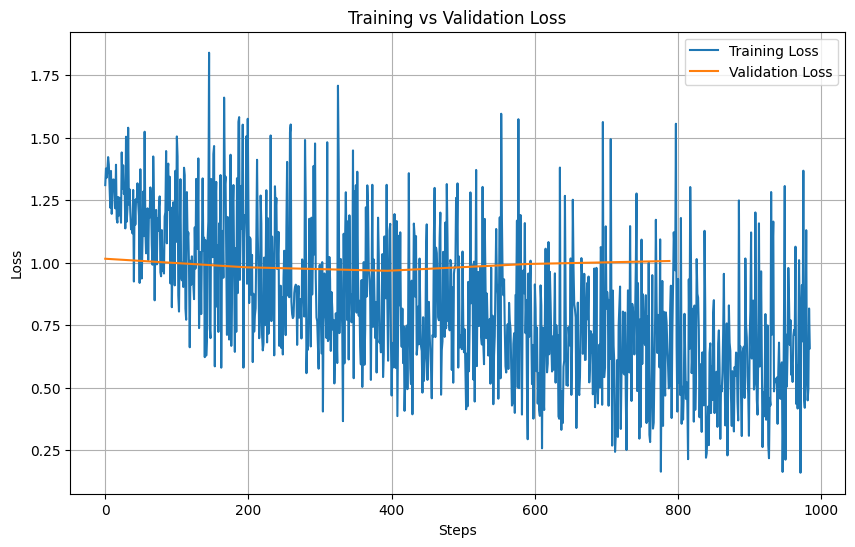

In [23]:
from matplotlib import pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(range(0, len(train_loss), len(train_loss)//len(val_loss)), val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
evaluation_results1 = trainer_s1.evaluate()
print(evaluation_results1)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 0.9671557545661926, 'eval_accuracy': 0.7969543147208121, 'eval_f1': 0.8029556650246306, 'eval_runtime': 4.5551, 'eval_samples_per_second': 172.994, 'eval_steps_per_second': 10.977, 'epoch': 5.0}


In [25]:
pred1 = trainer_s1.predict(test_dataset_1)
pred_label1 = pred1.predictions.argmax(axis=1)

y_test_numeric = y_test

print(classification_report(y_test_numeric, pred_label1))

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


              precision    recall  f1-score   support

           0       0.83      0.76      0.79       400
           1       0.77      0.84      0.80       388

    accuracy                           0.80       788
   macro avg       0.80      0.80      0.80       788
weighted avg       0.80      0.80      0.80       788



In [26]:
model_s1.save_pretrained("/kaggle/working/indobertweet_toxic_s1")
tokenizer.save_pretrained("/kaggle/working/indobertweet_toxic_s1")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/kaggle/working/indobertweet_toxic_s1/tokenizer_config.json',
 '/kaggle/working/indobertweet_toxic_s1/tokenizer.json')

In [27]:
import shutil

shutil.make_archive(
    "indobertweet_toxic_s1",
    "zip",
    "/kaggle/working/indobertweet_toxic_s1"
)

'/kaggle/working/indobertweet_toxic_s1.zip'

# Model Stage 2

## Use No Polarization

In [28]:
df_toxic = df[df["toxicity"] == 1].copy()

In [29]:
LABEL_COLS = [
    "insults",
    "identity_attack",
    "threat_incitement_to_violence",
    "profanity_obscenity",
    "sexually_explicit"
]

X = df_toxic["processed_text"]
y2 = df_toxic[LABEL_COLS]

In [30]:
!pip install iterative-stratification

In [31]:
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

import numpy as np

X_np = X.values
y_np = y2.values

mskf = MultilabelStratifiedKFold(n_splits=10, shuffle=True, random_state=42)

train_idx, test_idx = next(mskf.split(X_np, y_np))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y2.iloc[train_idx], y2.iloc[test_idx]

In [32]:
y_train = y_train.astype(float)
y_test  = y_test.astype(float)

In [33]:

from datasets import Dataset

train_df = X_train.to_frame()
train_df["labels"] = y_train.values.tolist()

test_df = X_test.to_frame()
test_df["labels"] = y_test.values.tolist()

train_ds = Dataset.from_pandas(train_df)
test_ds  = Dataset.from_pandas(test_df)

In [34]:
from transformers import AutoTokenizer

tokenizer_s2 = AutoTokenizer.from_pretrained(
    "indolem/indobertweet-base-uncased"
)

In [35]:
def tokenize(batch):
    return tokenizer_s2(
        batch["processed_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [36]:
train_ds = train_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

Map:   0%|          | 0/1743 [00:00<?, ? examples/s]

Map:   0%|          | 0/193 [00:00<?, ? examples/s]

In [37]:

from transformers import AutoModelForSequenceClassification

model_s2 = AutoModelForSequenceClassification.from_pretrained(
    "indolem/indobertweet-base-uncased",
    num_labels=len(LABEL_COLS),
    problem_type="multi_label_classification"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        targets = targets.float()

        bce_loss = F.binary_cross_entropy_with_logits(
            logits, targets, reduction='none'
        )

        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)

        focal_weight = (1 - pt) ** self.gamma
        loss = focal_weight * bce_loss

        if self.alpha is not None:
            alpha_t = torch.where(targets == 1, self.alpha, 1 - self.alpha)
            loss = alpha_t * loss

        return loss.mean()

In [46]:
from transformers import Trainer

class FocalTrainer(Trainer):
    def __init__(self, *args, loss_fn=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.loss_fn = loss_fn

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")

        outputs = model(**inputs)
        logits = outputs.logits

        loss = self.loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [40]:
loss_fn = FocalLoss(gamma=2)

In [41]:
import numpy as np
from sklearn.metrics import f1_score

def compute_metrics_s2(eval_pred):
    logits, labels = eval_pred

    probs = 1 / (1 + np.exp(-logits))  # sigmoid
    preds = (probs > 0.5).astype(int)

    return {
        "f1_micro": f1_score(labels, preds, average="micro"),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

In [43]:
args_s2 = TrainingArguments(
    output_dir="./model_toxicity_s2",
    num_train_epochs=5,
    logging_steps=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate = 1e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)

In [47]:
trainer_s2 = FocalTrainer(
    model=model_s2,
    args=args_s2,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics_s2,
    loss_fn=loss_fn
)

In [48]:
trainer_s2.train()

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro
1,0.142145,0.091844,0.365079,0.193997
2,0.078153,0.087286,0.453947,0.275387
3,0.108466,0.085360,0.481356,0.385402
4,0.071381,0.085154,0.512500,0.400616
5,0.100617,0.084581,0.498382,0.391926


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=545, training_loss=0.08730615749271638, metrics={'train_runtime': 170.6445, 'train_samples_per_second': 51.071, 'train_steps_per_second': 3.194, 'total_flos': 573268652893440.0, 'train_loss': 0.08730615749271638, 'epoch': 5.0})

In [49]:
history_s2 = trainer_s2.state.log_history
train_loss_s2 = [x['loss'] for x in history if 'loss' in x]
val_loss_s2 = [x['eval_loss'] for x in history if 'eval_loss' in x]
epochs_s2 = [x['epoch'] for x in history if 'eval_loss' in x]

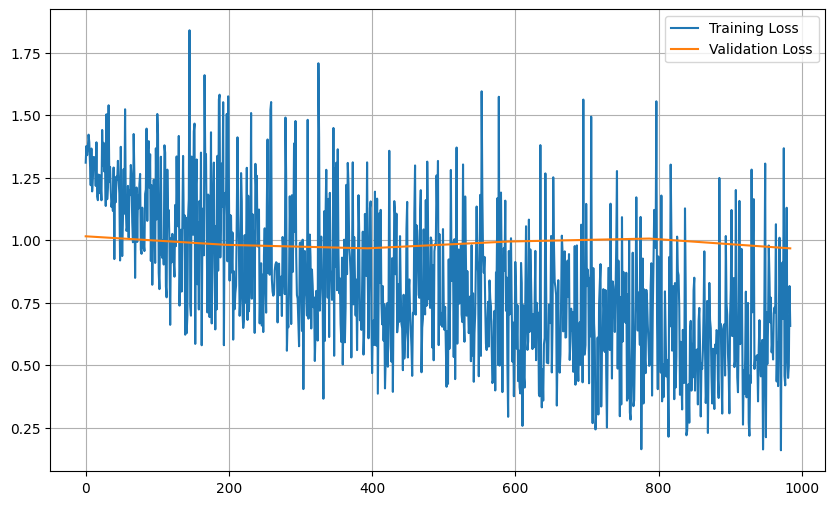

In [50]:
plt.figure(figsize=(10, 6))

plt.plot(train_loss_s2, label='Training Loss')

plt.plot(
    np.linspace(0, len(train_loss_s2)-1, len(val_loss_s2)),
    val_loss_s2,
    label='Validation Loss'
)

plt.legend()
plt.grid(True)
plt.show()

In [51]:
evaluation_results2 = trainer_s2.evaluate()
print(evaluation_results2)

{'eval_loss': 0.0845806747674942, 'eval_f1_micro': 0.49838187702265374, 'eval_f1_macro': 0.3919258127132143, 'eval_runtime': 1.2285, 'eval_samples_per_second': 157.103, 'eval_steps_per_second': 10.582, 'epoch': 5.0}


In [54]:
df_toxic['threat_incitement_to_violence'].value_counts()

threat_incitement_to_violence
0    1854
1      82
Name: count, dtype: int64

In [55]:
df_toxic['sexually_explicit'].value_counts()

sexually_explicit
0    1894
1      42
Name: count, dtype: int64

In [52]:
pred2 = trainer_s2.predict(test_ds)

import numpy as np

logits = pred2.predictions
probs = 1 / (1 + np.exp(-logits))

threshold = 0.5  # bisa tuning nanti
pred_label2 = (probs > threshold).astype(int)

y_true = y_test.values
from sklearn.metrics import classification_report

print(classification_report(y_true, pred_label2, target_names=LABEL_COLS))

                               precision    recall  f1-score   support

                      insults       0.56      0.46      0.50        70
              identity_attack       0.58      0.47      0.52        73
threat_incitement_to_violence       0.00      0.00      0.00         8
          profanity_obscenity       0.77      0.42      0.54        24
            sexually_explicit       1.00      0.25      0.40         4

                    micro avg       0.59      0.43      0.50       179
                    macro avg       0.58      0.32      0.39       179
                 weighted avg       0.58      0.43      0.49       179
                  samples avg       0.38      0.33      0.35       179



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

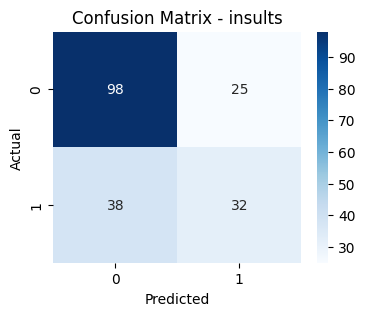

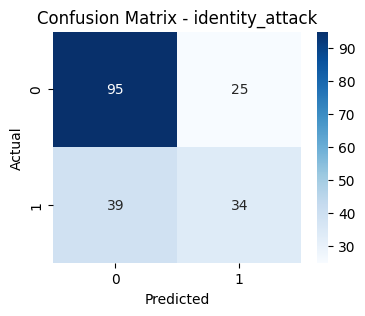

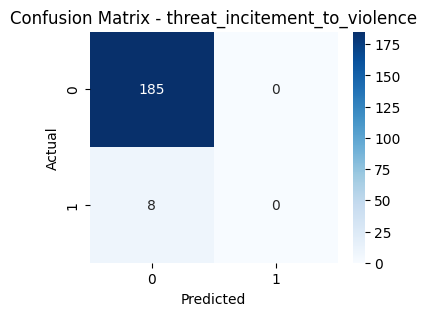

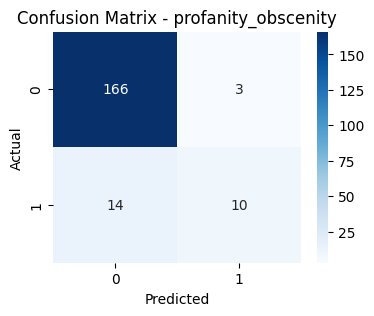

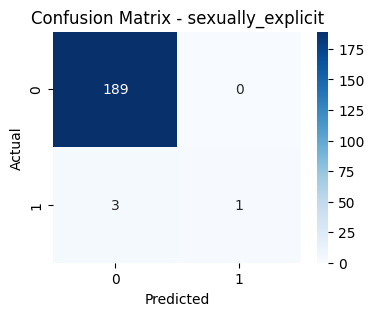

In [56]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

for i, label in enumerate(LABEL_COLS):
    cm = confusion_matrix(y_true[:, i], pred_label2[:, i])

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(f'Confusion Matrix - {label}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [57]:
model_s2.save_pretrained("/kaggle/working/indobertweet_toxic_s2_noPolar")
tokenizer_s2.save_pretrained("/kaggle/working/indobertweet_toxic_s2_noPolar")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/kaggle/working/indobertweet_toxic_s2_noPolar/tokenizer_config.json',
 '/kaggle/working/indobertweet_toxic_s2_noPolar/tokenizer.json')

In [58]:
import shutil

shutil.make_archive(
    "indobertweet_toxic_s2_noPolar",
    "zip",
    "/kaggle/working/indobertweet_toxic_s2_noPolar"
)

'/kaggle/working/indobertweet_toxic_s2_noPolar.zip'

## Use Polarization

In [59]:
df_final = df.copy()

In [60]:
def add_polarization_text(row):
    return f"[POL={row['polarized']}] {row['processed_text']}"

df_final["text_with_pol"] = df_final.apply(add_polarization_text, axis=1)

In [61]:
df_final

,text_id,annotators_id,text,initial_paragraph,topic,is_noise_or_spam_text,related_to_election_2024,toxicity,polarized,profanity_obscenity,threat_incitement_to_violence,insults,identity_attack,sexually_explicit,cleaned_text,processed_text,text_with_pol
0,1-1022,"['10', '18']",Video Adanya Beras Palsu Asal China Beredar di...,"Liputan6.com, Jakarta - Beredar di media sosia...",Tionghoa,0,0,0,1,0,0,0,0,0,Video Adanya Beras Palsu Asal China Beredar di...,video adanya beras palsu asal china beredar di...,[POL=1] video adanya beras palsu asal china be...
1,1-1023,"['10', '18']",Para Pemuda Tiongkok RRC Akan Membanjiri Posis...,“PARA PEMUDA CINA AKAN MEMBANJIRI PEGAWAI NEGE...,UNKNOWN,0,0,0,1,0,0,0,0,0,Para Pemuda Tiongkok RRC Akan Membanjiri Posis...,para pemuda tiongkok rrc akan membanjiri posis...,[POL=1] para pemuda tiongkok rrc akan membanji...
2,1-1024,"['10', '18']",Prabowo bersama TNI Turun Tangan Bela Rakyat R...,"WOW! PRABOWO, SBY & GATOT NURMANTYO BERSAMA TN...",Tionghoa,0,0,0,1,0,0,0,0,0,Prabowo bersama TNI Turun Tangan Bela Rakyat R...,prabowo bersama tni turun tangan bela rakyat r...,[POL=1] prabowo bersama tni turun tangan bela ...
3,1-1037,"['10', '18']",Relawan Tionghoa Kalbar “All Out” Dukung Ganja...,NaN,Tionghoa,0,1,0,1,0,0,0,0,0,Relawan Tionghoa Kalbar “All Out” Dukung Ganja...,relawan tionghoa kalbar all out dukung ganjar ...,[POL=1] relawan tionghoa kalbar all out dukung...
4,1-1045,"['10', '18', '32']","Dukung Ganjar, Etnis Tionghoa Singgung Pemimpi...",NaN,Tionghoa,0,1,0,1,0,0,0,0,0,"Dukung Ganjar, Etnis Tionghoa Singgung Pemimpi...","dukung ganjar, etnis tionghoa singgung pemimpi...","[POL=1] dukung ganjar, etnis tionghoa singgung..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3931,4-928,"['19', '18']",@tanyakanrl Salah satu kejahatan dari houthi s...,NaN,Syiah,0,0,1,1,0,0,0,1,0,@tanyakanrl Salah satu kejahatan dari houthi s...,salah satu kejahatan dari houthi syiah rafidha...,[POL=1] salah satu kejahatan dari houthi syiah...
3932,4-942,['19'],@Heraloebss Usir Rohingya dari Aceh dan dari s...,NaN,Rohingya,0,0,1,1,0,1,0,1,0,@Heraloebss Usir Rohingya dari Aceh dan seluru...,usir rohingya dari aceh dan seluruh wilayah nk...,[POL=1] usir rohingya dari aceh dan seluruh wi...
3933,4-947,['19'],Bismillah... Semoga orang yang mati-matian mem...,NaN,Syiah,0,0,1,1,0,0,0,1,0,Bismillah... Semoga orang yang mati‑mati membe...,bismillah.. semoga orang yang matimati membela...,[POL=1] bismillah.. semoga orang yang matimati...
3934,4-961,"['19', '18']","Gila ya , kalau umat bersatu habis juga itu ge...",NaN,"LGBTQ+, Jewish, Disabilitas",0,0,1,1,0,0,1,0,0,"Gila ya, kalau umat bersatu habis juga itu ger...","gila ya, kalau umat bersatu habis juga itu ger...","[POL=1] gila ya, kalau umat bersatu habis juga..."


In [62]:
LABEL_COLS = [
    "insults",
    "identity_attack",
    "threat_incitement_to_violence",
    "profanity_obscenity",
    "sexually_explicit"
]

X = df_final["text_with_pol"]
y2 = df_final[LABEL_COLS]

In [63]:
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

import numpy as np

X_np = X.values
y_np = y2.values

mskf = MultilabelStratifiedKFold(n_splits=10, shuffle=True, random_state=42)

train_idx, test_idx = next(mskf.split(X_np, y_np))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y2.iloc[train_idx], y2.iloc[test_idx]

In [64]:
y_train = y_train.astype(float)
y_test  = y_test.astype(float)

In [65]:

from datasets import Dataset

train_df = X_train.to_frame()
train_df["labels"] = y_train.values.tolist()

test_df = X_test.to_frame()
test_df["labels"] = y_test.values.tolist()

train_ds = Dataset.from_pandas(train_df)
test_ds  = Dataset.from_pandas(test_df)

In [66]:
from transformers import AutoTokenizer

tokenizer_s2_2 = AutoTokenizer.from_pretrained(
    "indolem/indobertweet-base-uncased"
)

In [68]:
def tokenize(batch):
    return tokenizer_s2_2(
        batch["text_with_pol"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_ds = train_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

Map:   0%|          | 0/3542 [00:00<?, ? examples/s]

Map:   0%|          | 0/394 [00:00<?, ? examples/s]

In [69]:

from transformers import AutoModelForSequenceClassification

model_s2_2 = AutoModelForSequenceClassification.from_pretrained(
    "indolem/indobertweet-base-uncased",
    num_labels=len(LABEL_COLS),
    problem_type="multi_label_classification"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [70]:
import numpy as np
from sklearn.metrics import f1_score

def compute_metrics_s2_2(eval_pred):
    logits, labels = eval_pred

    probs = 1 / (1 + np.exp(-logits))  # sigmoid
    preds = (probs > 0.5).astype(int)

    return {
        "f1_micro": f1_score(labels, preds, average="micro"),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

In [71]:
args_s2_2 = TrainingArguments(
    output_dir="./model_toxicity_s2_2",
    num_train_epochs=5,
    logging_steps=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate = 1e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)

In [72]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        targets = targets.float()

        bce_loss = F.binary_cross_entropy_with_logits(
            logits, targets, reduction='none'
        )

        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)

        focal_weight = (1 - pt) ** self.gamma
        loss = focal_weight * bce_loss

        if self.alpha is not None:
            alpha_t = torch.where(targets == 1, self.alpha, 1 - self.alpha)
            loss = alpha_t * loss

        return loss.mean()

In [73]:
from transformers import Trainer

class FocalTrainer(Trainer):
    def __init__(self, *args, loss_fn=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.loss_fn = loss_fn

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")

        outputs = model(**inputs)
        logits = outputs.logits

        loss = self.loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [74]:
loss_fn = FocalLoss(gamma=2)

In [75]:
trainer_s2_2 = FocalTrainer(
    model=model_s2_2,
    args=args_s2_2,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics_s2_2,
    loss_fn=loss_fn
)

In [79]:
trainer_s2_2.train()

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro
1,0.018336,0.057630,0.392982,0.362312
2,0.030961,0.057143,0.476190,0.408792
3,0.023242,0.060225,0.450000,0.386585
4,0.019808,0.064557,0.440895,0.380004
5,0.032828,0.066000,0.447205,0.387970


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1110, training_loss=0.03337661136478723, metrics={'train_runtime': 336.8862, 'train_samples_per_second': 52.57, 'train_steps_per_second': 3.295, 'total_flos': 1164955575759360.0, 'train_loss': 0.03337661136478723, 'epoch': 5.0})

In [80]:
history_s2_2 = trainer_s2_2.state.log_history
train_loss_s2_2 = [x['loss'] for x in history_s2_2 if 'loss' in x]
val_loss_s2_2 = [x['eval_loss'] for x in history_s2_2 if 'eval_loss' in x]
epochs_s2_2 = [x['epoch'] for x in history_s2_2 if 'eval_loss' in x]

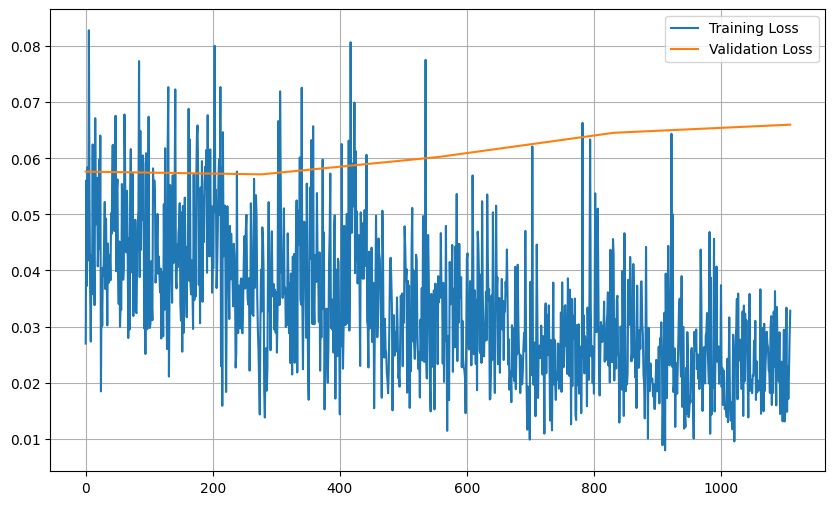

In [81]:
plt.figure(figsize=(10, 6))

plt.plot(train_loss_s2_2, label='Training Loss')

plt.plot(
    np.linspace(0, len(train_loss_s2_2)-1, len(val_loss_s2_2)),
    val_loss_s2_2,
    label='Validation Loss'
)

plt.legend()
plt.grid(True)
plt.show()

In [82]:
evaluation_results2_2 = trainer_s2_2.evaluate()
print(evaluation_results2_2)

{'eval_loss': 0.05713920667767525, 'eval_f1_micro': 0.47752808988764045, 'eval_f1_macro': 0.4093940425798201, 'eval_runtime': 2.3616, 'eval_samples_per_second': 166.833, 'eval_steps_per_second': 10.586, 'epoch': 5.0}


In [83]:
pred2_2 = trainer_s2_2.predict(test_ds)

In [84]:

import numpy as np

logits = pred2_2.predictions
probs = 1 / (1 + np.exp(-logits))

threshold = 0.5  # bisa tuning nanti
pred_label2_2 = (probs > threshold).astype(int)

y_true = y_test.values
from sklearn.metrics import classification_report

print(classification_report(y_true, pred_label2_2, target_names=LABEL_COLS))

                               precision    recall  f1-score   support

                      insults       0.54      0.59      0.56        71
              identity_attack       0.44      0.42      0.43        73
threat_incitement_to_violence       0.00      0.00      0.00         8
          profanity_obscenity       0.39      0.38      0.38        24
            sexually_explicit       0.75      0.60      0.67         5

                    micro avg       0.49      0.47      0.48       181
                    macro avg       0.42      0.40      0.41       181
                 weighted avg       0.46      0.47      0.47       181
                  samples avg       0.18      0.19      0.18       181



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

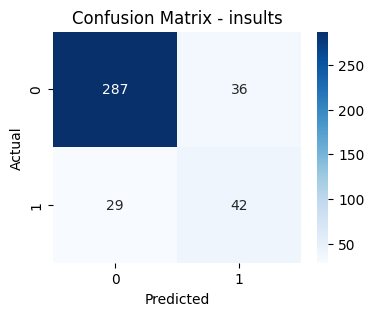

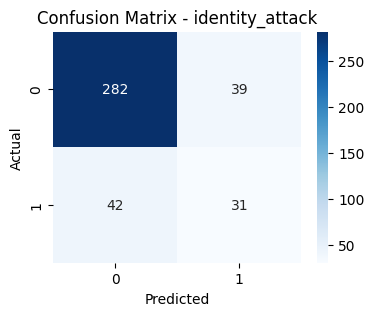

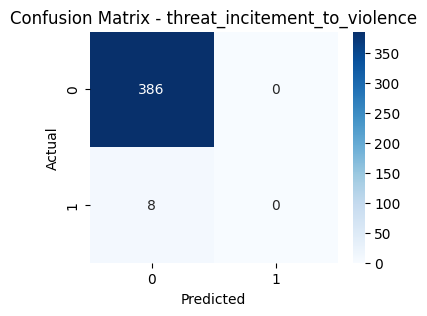

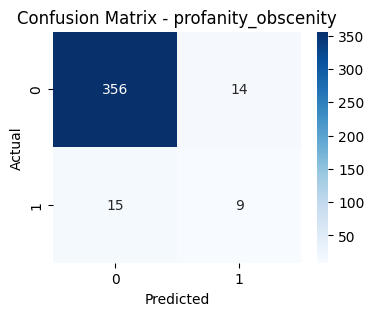

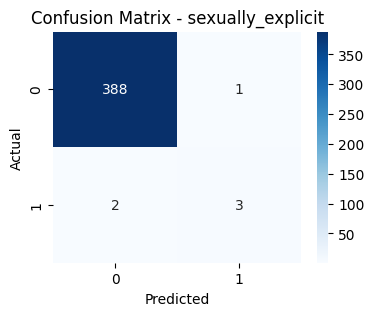

In [85]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

for i, label in enumerate(LABEL_COLS):
    cm = confusion_matrix(y_true[:, i], pred_label2_2[:, i])

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(f'Confusion Matrix - {label}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [86]:
model_s2_2.save_pretrained("/kaggle/working/indobertweet_toxic_s2_Polar")
tokenizer_s2_2.save_pretrained("/kaggle/working/indobertweet_toxic_s2_Polar")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/kaggle/working/indobertweet_toxic_s2_Polar/tokenizer_config.json',
 '/kaggle/working/indobertweet_toxic_s2_Polar/tokenizer.json')

In [87]:
import shutil

shutil.make_archive(
    "indobertweet_toxic_s2_Polar",
    "zip",
    "/kaggle/working/indobertweet_toxic_s2_Polar"
)

'/kaggle/working/indobertweet_toxic_s2_Polar.zip'